# Unit 5 — 04: Detecting Data Drift in Production

**What you will do:** Apply three statistical methods to detect when the distribution of production data is shifting away from training data — KS test, Population Stability Index (PSI), and Jensen-Shannon divergence.

**Why it matters:** A model can look healthy (no errors, normal latency) while silently degrading because it is being asked to predict on data it has never seen before. Drift detection catches this early.

**How to run:** Python 3.10+. Run cells in order.

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 5, lesson 07 "Implementing Hypothesis Testing Procedures" — the Kolmogorov-Smirnov test used here is a hypothesis test; drift detection is that test run continuously against the training distribution, which is also why a threshold that fires every day is telling you nothing.

---

## 📰 Google Flu Trends was wrong for two years and nobody noticed from the code

Google Flu Trends estimated influenza prevalence from search queries and was, for a while, the standard example of big data outperforming traditional surveillance. Then Lazer, Kennedy, King and Vespignani published *The Parable of Google Flu: Traps in Big Data Analysis* in **Science** in **2014**. Their finding: between **21 August 2011 and 1 September 2013, GFT overestimated flu prevalence in 100 of 108 weeks** — and at its worst was predicting **more than double** the proportion of influenza-like-illness doctor visits that the CDC actually recorded.

The system never crashed. Latency never moved. The model produced a number every week, on time, and the number was wrong for two years. What had changed was the relationship between search behaviour and illness — partly because Google itself kept changing search, and partly because a flu-season media cycle makes healthy people search for flu. **This is what drift looks like from the inside: nothing breaks.**

**What goes wrong without this lesson.** Without an explicit comparison between the data the model was trained on and the data it is receiving now, degradation is invisible until labels arrive — which in health, credit and insurance can be months. The three methods below (KS, PSI, Jensen-Shannon) are the standard toolkit for making that comparison, and — as you are about to see — they do not always agree with each other.

## Section 1 — Data Drift vs Concept Drift

**Data drift (covariate shift):** The distribution of input features P(X) changes, but the relationship between inputs and outputs P(Y|X) remains the same.  
Example: A fraud detection model trained on desktop transactions starts receiving mostly mobile transactions. Feature distributions shift (session length, device type) even though fraud still looks the same.

**Concept drift:** The relationship P(Y|X) itself changes — the same features now mean something different.  
Example: A credit scoring model trained before a recession. After the recession, the same income and debt ratios no longer predict default the same way.

**Why the distinction matters:** Data drift can sometimes be handled by retraining on more diverse data. Concept drift may require rethinking the features entirely.

## Section 2 — Kolmogorov-Smirnov Test for Numerical Features

The KS test measures the maximum difference between two cumulative distribution functions.  
- `p-value` is the probability of a gap between the two CDFs **at least this large** if both samples came from the *same* distribution — exactly the definition you met in Course 03 (AIAT 113), Unit 5, lesson 07. It is **not** the probability that the feature drifted, and **not** the probability that the difference arose by chance.
- `p-value < 0.05` is therefore a **threshold we choose, not a verdict the test hands us**: the observed gap would be unlikely under "nothing changed", so we flag the feature and investigate. Read the `⚠️ Where this breaks` cell before you page anyone on it.
- `ks_stat` tells you how large the shift is (0 = identical, 1 = completely different).

KS statistic: 0.2360
p-value:      0.000000
Conclusion:   DRIFT DETECTED


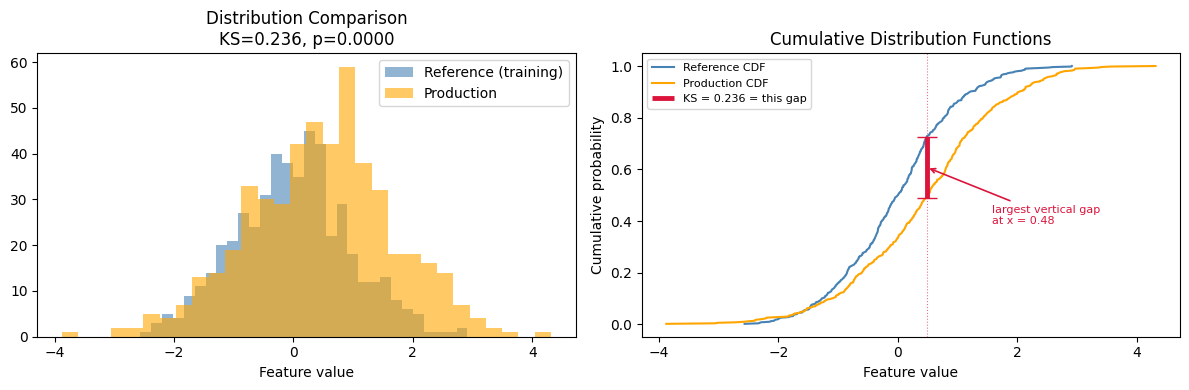

The KS statistic is the maximum vertical gap between the two CDF lines: 0.2360 at feature value 0.48.
At that value 72.6% of the reference sample has been seen but only 49.0% of the production sample — the production distribution is running 23.6% 'behind'.


In [1]:
# WHAT: introduce the Kolmogorov-Smirnov test on two synthetic distributions,
# with histograms and the CDFs the test actually compares.
# WHY: KS is the workhorse of drift detection — one number (max CDF gap) plus
# a p-value that an automated monitor can threshold.
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

rng = np.random.default_rng(42)

# Reference distribution: normal(0, 1)
reference = rng.normal(loc=0.0, scale=1.0, size=500)

# Production distribution: shifted to normal(0.5, 1.2)
production = rng.normal(loc=0.5, scale=1.2, size=500)

ks_stat, p_value = sp_stats.ks_2samp(reference, production)
print(f"KS statistic: {ks_stat:.4f}")
print(f"p-value:      {p_value:.6f}")
print(f"Conclusion:   {'DRIFT DETECTED' if p_value < 0.05 else 'No significant drift'}")

# Visualise the two distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(reference, bins=30, alpha=0.6, label="Reference (training)", color="steelblue")
axes[0].hist(production, bins=30, alpha=0.6, label="Production", color="orange")
axes[0].set_title(f"Distribution Comparison\nKS={ks_stat:.3f}, p={p_value:.4f}")
axes[0].legend()
axes[0].set_xlabel("Feature value")

# Cumulative distributions (what KS test actually compares)
ref_sorted = np.sort(reference)
prod_sorted = np.sort(production)
ref_cdf = np.arange(1, len(ref_sorted) + 1) / len(ref_sorted)
prod_cdf = np.arange(1, len(prod_sorted) + 1) / len(prod_sorted)
axes[1].plot(ref_sorted, ref_cdf, label="Reference CDF", color="steelblue")
axes[1].plot(prod_sorted, prod_cdf, label="Production CDF", color="orange")

# Find and DRAW the KS statistic: evaluate both empirical CDFs on the merged set
# of observed values, then take the single x where they are furthest apart.
grid = np.sort(np.concatenate([ref_sorted, prod_sorted]))
ref_at_grid = np.searchsorted(ref_sorted, grid, side="right") / len(ref_sorted)
prod_at_grid = np.searchsorted(prod_sorted, grid, side="right") / len(prod_sorted)
gaps = np.abs(ref_at_grid - prod_at_grid)
j = int(np.argmax(gaps))
x_gap, lo, hi = grid[j], min(ref_at_grid[j], prod_at_grid[j]), max(ref_at_grid[j], prod_at_grid[j])

axes[1].vlines(x_gap, lo, hi, color="crimson", linewidth=3.5,
               label=f"KS = {gaps[j]:.3f} = this gap")
axes[1].plot([x_gap, x_gap], [lo, hi], "_", color="crimson", markersize=14)
axes[1].annotate(f"largest vertical gap\nat x = {x_gap:.2f}",
                 xy=(x_gap, (lo + hi) / 2), xytext=(x_gap + 1.1, (lo + hi) / 2 - 0.22),
                 fontsize=8, color="crimson",
                 arrowprops=dict(arrowstyle="->", color="crimson", lw=1.2))
axes[1].axvline(x_gap, color="crimson", linestyle=":", linewidth=0.8, alpha=0.6)
axes[1].set_title("Cumulative Distribution Functions")
axes[1].set_xlabel("Feature value")
axes[1].set_ylabel("Cumulative probability")
axes[1].legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig("/tmp/drift_ks_basic.png", dpi=72)
plt.show()
print(f"The KS statistic is the maximum vertical gap between the two CDF lines: "
      f"{gaps[j]:.4f} at feature value {x_gap:.2f}.")
print(f"At that value {ref_at_grid[j]:.1%} of the reference sample has been seen "
      f"but only {prod_at_grid[j]:.1%} of the production sample — the production "
      f"distribution is running {gaps[j]:.1%} 'behind'.")

**Read the figure.** Left: the two histograms overlap heavily — that is the honest visual impression of a 0.5 shift in a distribution whose spread is 1.0, and it is why eyeballing histograms is a bad drift detector. Right: the same two samples as cumulative curves. Across almost the whole range the orange production curve sits to the *right* of the blue reference curve — it takes a higher feature value to reach the same cumulative probability — and the thick red bar marks the one place where the vertical distance between them is largest. **That red bar is the KS statistic** — not a summary of it, the thing itself. Its length is the number printed in the left panel's title.

**What it proves.** KS reduces a whole distribution comparison to one measurable distance, which is what makes it automatable: a monitor can threshold that length every hour without a human looking at a histogram. It also shows the method's blind spot in advance — a change that does not move the CDFs apart *vertically* produces a small statistic no matter how different the distributions look, which is exactly what happens in Section 5.

## Section 3 — Apply KS Test to Iris Features

Simulate 200 production samples with a gradual shift. Run KS test per feature to see which features drift first.

In [2]:
# WHAT: apply the KS test per FEATURE — training data vs a simulated production
# batch whose drift grows gradually.
# WHY: real drift rarely hits all features equally; per-feature tests tell you
# WHICH input changed, the first clue to the root cause.
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

feature_names = iris.feature_names

# Simulate production samples with increasing drift
N_PROD = 200
drift_levels = np.linspace(0, 1.5, N_PROD)  # drift grows gradually
# X_test has fewer than N_PROD rows, so sample with replacement to build the
# production batch, then add gradually increasing drift to each sample.
idx = rng.integers(0, len(X_test), size=N_PROD)
X_prod = X_test[idx].copy()
for i in range(N_PROD):
    X_prod[i] = X_prod[i] + drift_levels[i] * rng.normal(0, 0.5, size=4)

# One row per feature: statistic, p-value, and the drift verdict at alpha=0.05.
print("KS test results per feature (reference=training, production=shifted):")
print(f"{'Feature':<30} {'KS stat':<12} {'p-value':<12} {'Drift?'}")
print("-" * 65)
ks_results = []
for i, name in enumerate(feature_names):
    ks_stat, p_val = sp_stats.ks_2samp(X_train[:, i], X_prod[:, i])
    drifted = p_val < 0.05
    ks_results.append({"feature": name, "ks_stat": ks_stat, "p_value": p_val, "drifted": drifted})
    print(f"{name:<30} {ks_stat:<12.4f} {p_val:<12.4f} {'YES' if drifted else 'no'}")

KS test results per feature (reference=training, production=shifted):
Feature                        KS stat      p-value      Drift?
-----------------------------------------------------------------
sepal length (cm)              0.1094       0.4130       no
sepal width (cm)               0.1889       0.0204       YES
petal length (cm)              0.1083       0.4255       no
petal width (cm)               0.1828       0.0272       YES


## Section 4 — Population Stability Index (PSI) for Categorical Features

PSI compares the distribution of a categorical variable between reference and production:
- PSI < 0.1 → no meaningful drift
- 0.1 ≤ PSI < 0.2 → some drift, investigate
- PSI ≥ 0.2 → significant drift, action required

In [3]:
# WHAT: compute the Population Stability Index (PSI) on the model's PREDICTED
# class distribution — reference vs production.
# WHY: PSI monitors the model's OUTPUT side: if the class mix shifts, either the
# world changed or the model is misreading it — both worth an alert. The
# 0.1 / 0.2 bands are the standard industry interpretation.
from sklearn.ensemble import RandomForestClassifier


def compute_psi(reference_counts: np.ndarray, production_counts: np.ndarray) -> float:
    """
    Compute Population Stability Index from raw counts.
    Adds a small epsilon to avoid log(0).
    """
    eps = 1e-6
    ref_pct  = reference_counts  / reference_counts.sum()  + eps
    prod_pct = production_counts / production_counts.sum() + eps
    psi = float(np.sum((prod_pct - ref_pct) * np.log(prod_pct / ref_pct)))
    return psi


# Train a model and compare class prediction distribution between reference and production
clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(X_train, y_train)

ref_preds  = clf.predict(X_test)   # predictions on clean test data
prod_preds = clf.predict(X_prod)   # predictions on drifted production data

n_classes = len(iris.target_names)
ref_counts  = np.array([np.sum(ref_preds  == c) for c in range(n_classes)], dtype=float)
prod_counts = np.array([np.sum(prod_preds == c) for c in range(n_classes)], dtype=float)

psi_score = compute_psi(ref_counts, prod_counts)
print(f"Class distribution PSI: {psi_score:.4f}")
if psi_score < 0.1:
    print("Interpretation: No significant drift")
elif psi_score < 0.2:
    print("Interpretation: Some drift — investigate")
else:
    print("Interpretation: Significant drift — action required")

print("\nPrediction class distribution:")
print(f"{'Class':<15} {'Reference':>12} {'Production':>12}")
for i, name in enumerate(iris.target_names):
    ref_pct  = ref_counts[i]  / ref_counts.sum()  * 100
    prod_pct = prod_counts[i] / prod_counts.sum() * 100
    print(f"{name:<15} {ref_pct:>11.1f}% {prod_pct:>11.1f}%")

Class distribution PSI: 0.0082
Interpretation: No significant drift

Prediction class distribution:
Class              Reference   Production
setosa                 38.3%        34.0%
versicolor             33.3%        35.5%
virginica              28.3%        30.5%


## Section 5 — Drift Over Time (Sliding Window)

In production, drift accumulates gradually. A sliding window lets you track the KS statistic over time and ask whether the drift ever becomes significant at all. Read the result carefully — on this stream, the answer is not the one the section title leads you to expect.

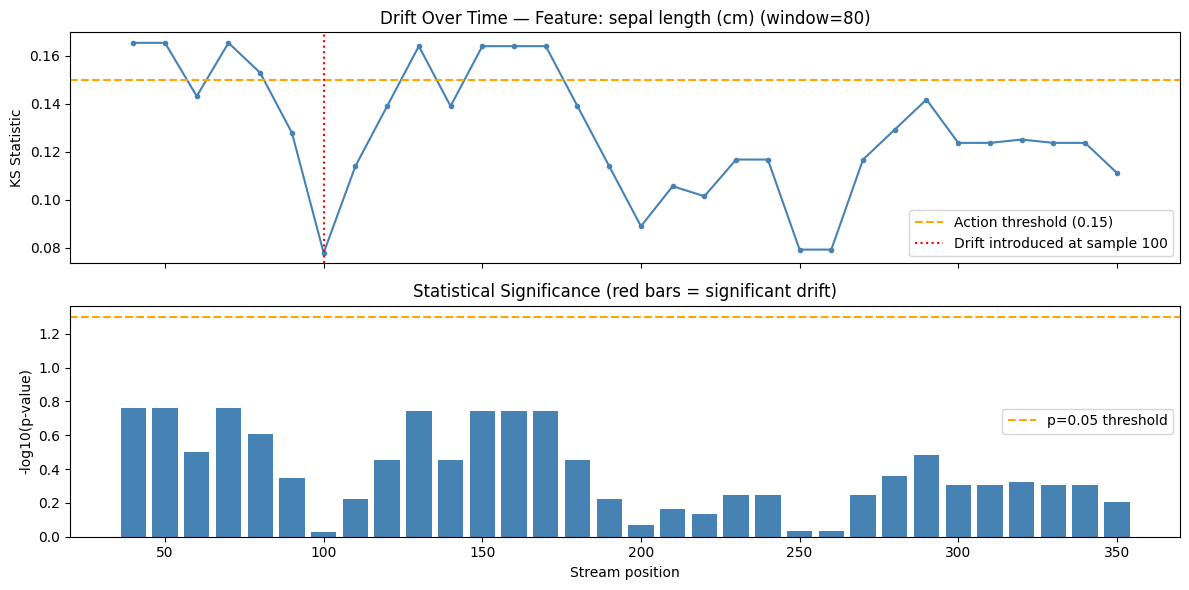

KS statistic across the stream: min 0.078, max 0.165.
Windows significant at p<0.05: 0 of 32. Windows above the 0.15 action threshold: 8.


In [4]:
# Generate a longer production stream with drift that starts at sample 100
N_STREAM = 400
n_clean, n_drift = 100, N_STREAM - 100
# X_test is smaller than N_STREAM, so sample with replacement to build the stream.
clean_idx = rng.integers(0, len(X_test), size=n_clean)
drift_idx = rng.integers(0, len(X_test), size=n_drift)
# Drift magnitude grows from 0 to ~1.2 across the drifted segment, so the KS
# statistic rises gradually rather than jumping at a single point.
drift_scale = np.linspace(0.0, 1.2, n_drift).reshape(-1, 1)
X_stream = np.vstack([
    X_test[clean_idx].copy(),                                                   # samples 0-99: no drift
    X_test[drift_idx].copy() + drift_scale * rng.normal(0, 0.5, (n_drift, 4)),  # 100-399: increasing drift
])

WINDOW = 80
FEATURE_IDX = 0  # track sepal length

ks_stats = []
p_values = []
positions = []

reference_feature = X_train[:, FEATURE_IDX]

for start in range(0, N_STREAM - WINDOW, 10):
    window_data = X_stream[start : start + WINDOW, FEATURE_IDX]
    ks, pval = sp_stats.ks_2samp(reference_feature, window_data)
    ks_stats.append(ks)
    p_values.append(pval)
    positions.append(start + WINDOW // 2)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(positions, ks_stats, color="steelblue", marker="o", markersize=3)
axes[0].axhline(0.15, color="orange", linestyle="--", label="Action threshold (0.15)")
axes[0].axvline(100, color="red", linestyle=":", label="Drift introduced at sample 100")
axes[0].set_ylabel("KS Statistic")
axes[0].set_title(f"Drift Over Time — Feature: {feature_names[FEATURE_IDX]} (window={WINDOW})")
axes[0].legend()

colors = ["red" if p < 0.05 else "steelblue" for p in p_values]
axes[1].bar(positions, [-np.log10(max(p, 1e-10)) for p in p_values], color=colors, width=8)
axes[1].axhline(-np.log10(0.05), color="orange", linestyle="--", label="p=0.05 threshold")
axes[1].set_ylabel("-log10(p-value)")
axes[1].set_xlabel("Stream position")
axes[1].set_title("Statistical Significance (red bars = significant drift)")
axes[1].legend()

plt.tight_layout()
plt.savefig("/tmp/drift_over_time.png", dpi=72)
plt.show()
# Report what the run actually produced, not what we hoped it would.
n_signif = sum(p < 0.05 for p in p_values)
print(f"KS statistic across the stream: min {min(ks_stats):.3f}, max {max(ks_stats):.3f}.")
print(f"Windows significant at p<0.05: {n_signif} of {len(p_values)}. "
      f"Windows above the 0.15 action threshold: {sum(k > 0.15 for k in ks_stats)}.")

## 👁️ See it — what the sliding window is actually looking at

The panel above plots one number per window. It does not show you the distributions that number came from, so it cannot tell you *why* the KS statistic behaves as it does. The storyboard below freezes the window at five positions along the same stream and draws the histogram the test is comparing against the fixed reference.

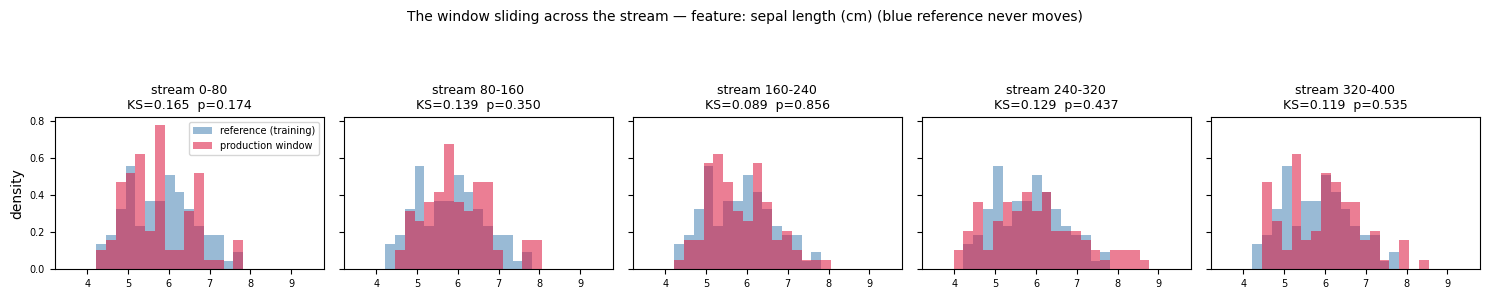

reference: mean 5.82, sd 0.81
window           mean     sd    min    max      KS       p
----------------------------------------------------------
0-80          5.70   0.79   4.40   7.70   0.165   0.174
80-160         5.99   0.81   4.61   7.95   0.139   0.350
160-240         5.82   0.79   4.40   7.89   0.089   0.856
240-320         5.97   1.12   4.07   8.59   0.129   0.437
320-400         5.97   0.91   4.49   8.36   0.119   0.535


In [5]:
# WHAT: storyboard the sliding window — reference histogram (blue, fixed) against
# the window's own histogram (red, moving) at five positions in the stream.
# WHY: the KS statistic is a summary of exactly this comparison. Seeing the two
# histograms explains why the number does what it does.
frame_starts = [0, 80, 160, 240, 320]
reference_feature = X_train[:, FEATURE_IDX]
shared_bins = np.linspace(3.5, 9.5, 26)   # same bins in every panel: honest comparison

fig, axes = plt.subplots(1, len(frame_starts), figsize=(15, 3.0), sharey=True, sharex=True)
for ax, start in zip(axes, frame_starts):
    window_data = X_stream[start:start + WINDOW, FEATURE_IDX]
    ks, pval = sp_stats.ks_2samp(reference_feature, window_data)
    ax.hist(reference_feature, bins=shared_bins, density=True,
            color="steelblue", alpha=0.55, label="reference (training)")
    ax.hist(window_data, bins=shared_bins, density=True,
            color="crimson", alpha=0.55, label="production window")
    ax.set_title(f"stream {start}-{start + WINDOW}\nKS={ks:.3f}  p={pval:.3f}",
                 fontsize=9, color=("crimson" if pval < 0.05 else "black"))
    ax.tick_params(labelsize=7)
axes[0].set_ylabel("density")
axes[0].legend(fontsize=7)
fig.suptitle(f"The window sliding across the stream — feature: {feature_names[FEATURE_IDX]} "
             f"(blue reference never moves)", fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig("/tmp/drift_window_storyboard.png", dpi=72)
plt.show()

print(f"reference: mean {reference_feature.mean():.2f}, sd {reference_feature.std():.2f}")
print(f"{'window':<14}{'mean':>7}{'sd':>7}{'min':>7}{'max':>7}{'KS':>8}{'p':>8}")
print("-" * 58)
for start in frame_starts:
    w = X_stream[start:start + WINDOW, FEATURE_IDX]
    ks, pval = sp_stats.ks_2samp(reference_feature, w)
    print(f"{start}-{start + WINDOW:<9}{w.mean():>7.2f}{w.std():>7.2f}"
          f"{w.min():>7.2f}{w.max():>7.2f}{ks:>8.3f}{pval:>8.3f}")

**Read the storyboard.** The blue reference is identical in all five panels — that is the point of a reference window. The red production histogram moves, but look at *how*: its centre stays where it was (window means 5.70 to 5.99, against a reference mean of 5.82), while its edges creep outward (the minimum falls to about 4.1 and the maximum rises to about 8.6 in the later panels, and the standard deviation grows from 0.79 to as much as 1.12). The distribution is **spreading, not sliding**.

**What it proves.** This is why the KS panel above wanders between roughly 0.08 and 0.17 instead of climbing, and why **not one window reaches p < 0.05** — despite the stream being built with drift that grows continuously from sample 100 onwards. The KS statistic is the largest vertical gap between two CDFs, and a symmetric widening barely moves the CDF in the middle, where nearly all the probability mass sits. With only 80 samples per window, that gap stays inside what sampling noise alone would produce.

Two lessons follow, and they are worth more than a clean detection would have been. **First, drift has a shape.** A mean shift — a sensor recalibrated, a currency redenominated — is easy for KS. A variance increase — a noisier sensor, a wider customer mix — is nearly invisible to it at this sample size, even though it can hurt a model just as much. **Second, the notebook's own reference stream is the counter-example**: a detector that reports "no significant drift" is telling you about its power to detect the shape it is sensitive to, not about the health of your model.

## Section 6 — Jensen-Shannon Divergence

Jensen-Shannon (JS) divergence is a symmetric, bounded (0 to 1) measure of how similar two distributions are. It works well for comparing probability distributions derived from histograms.

In [6]:
# WHAT: compute Jensen-Shannon divergence per feature via shared-bin histograms.
# WHY: unlike the KS p-value, JS is a bounded [0,1] DISTANCE — better for
# dashboards and trend lines because it doesn't saturate with sample size.
from scipy.spatial.distance import jensenshannon


def compute_js_divergence(
    reference: np.ndarray, production: np.ndarray, n_bins: int = 20
) -> float:
    """
    Compute Jensen-Shannon divergence between two 1-D arrays
    by first converting them to histogram-based probability distributions.
    """
    # Use shared bin edges so both histograms are comparable
    combined_min = min(reference.min(), production.min())
    combined_max = max(reference.max(), production.max())
    bins = np.linspace(combined_min, combined_max, n_bins + 1)

    ref_hist,  _ = np.histogram(reference,  bins=bins, density=True)
    prod_hist, _ = np.histogram(production, bins=bins, density=True)

    # Add epsilon to avoid zero probabilities
    eps = 1e-8
    ref_hist  = ref_hist  + eps
    prod_hist = prod_hist + eps

    return float(jensenshannon(ref_hist, prod_hist))


# Same features as the KS table — compare how the two metrics rank the drift.
print("Jensen-Shannon divergence per iris feature:")
print(f"{'Feature':<30} {'JS divergence':<15} {'Interpretation'}")
print("-" * 65)

for i, name in enumerate(feature_names):
    js = compute_js_divergence(X_train[:, i], X_prod[:, i])
    if js < 0.05:
        interpretation = "No drift"
    elif js < 0.15:
        interpretation = "Mild drift"
    else:
        interpretation = "Significant drift"
    print(f"{name:<30} {js:<15.4f} {interpretation}")

print("\nJS divergence is 0 for identical distributions and approaches 1 for completely different ones.")

Jensen-Shannon divergence per iris feature:
Feature                        JS divergence   Interpretation
-----------------------------------------------------------------
sepal length (cm)              0.2509          Significant drift
sepal width (cm)               0.3005          Significant drift
petal length (cm)              0.2465          Significant drift
petal width (cm)               0.3481          Significant drift

JS divergence is 0 for identical distributions and approaches 1 for completely different ones.


## 👁️ See it — three detectors, one dataset, three verdicts

The Discuss cell below tabulates the disagreement. Put it on one axis first: KS statistic and Jensen-Shannon divergence are both computed per feature on the **same** 200 production rows, and PSI is computed on the model's **predicted classes** for those same rows.

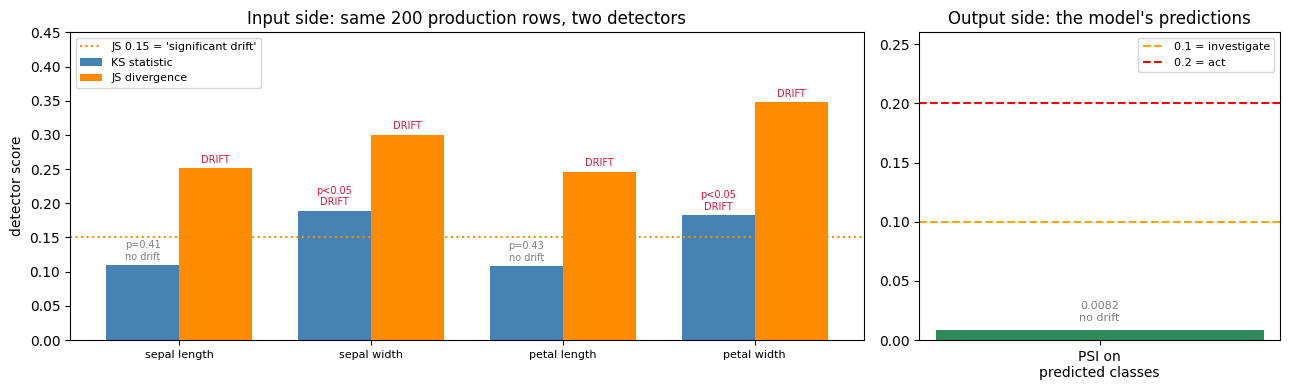

feature                 KS    KS p   KS says      JS   JS says
--------------------------------------------------------------
sepal length         0.109   0.413        no   0.251     DRIFT
sepal width          0.189   0.020     DRIFT   0.301     DRIFT
petal length         0.108   0.426        no   0.246     DRIFT
petal width          0.183   0.027     DRIFT   0.348     DRIFT

PSI on predicted classes: 0.0082 -> no drift


In [7]:
# WHAT: plot the three drift detectors side by side on the same production batch.
# WHY: they are usually shown in isolation, one per section, which hides the fact
# that they disagree. On one axis the disagreement is impossible to miss.
js_per_feature = [compute_js_divergence(X_train[:, i], X_prod[:, i]) for i in range(4)]
ks_per_feature = [r["ks_stat"] for r in ks_results]
ks_drifted     = [r["drifted"] for r in ks_results]
short_names    = [n.replace(" (cm)", "") for n in feature_names]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2.2, 1]})

x = np.arange(4)
bar_w = 0.38
axes[0].bar(x - bar_w / 2, ks_per_feature, bar_w, color="steelblue", label="KS statistic")
axes[0].bar(x + bar_w / 2, js_per_feature, bar_w, color="darkorange", label="JS divergence")
axes[0].axhline(0.15, color="darkorange", linestyle=":", linewidth=1.5,
                label="JS 0.15 = 'significant drift'")
# Label each bar with the verdict its own convention produces.
for i, (v, flagged) in enumerate(zip(ks_per_feature, ks_drifted)):
    axes[0].text(i - bar_w / 2, v + 0.008,
                 "p<0.05\nDRIFT" if flagged else f"p={ks_results[i]['p_value']:.2f}\nno drift",
                 ha="center", fontsize=7, color=("crimson" if flagged else "grey"))
for i, v in enumerate(js_per_feature):
    axes[0].text(i + bar_w / 2, v + 0.008, "DRIFT", ha="center", fontsize=7, color="crimson")
axes[0].set_xticks(x); axes[0].set_xticklabels(short_names, fontsize=8)
axes[0].set_ylim(0, 0.45); axes[0].set_ylabel("detector score")
axes[0].set_title("Input side: same 200 production rows, two detectors")
axes[0].legend(fontsize=8, loc="upper left")

axes[1].bar(["PSI on\npredicted classes"], [psi_score], color="seagreen", width=0.45)
axes[1].axhline(0.1, color="orange", linestyle="--", label="0.1 = investigate")
axes[1].axhline(0.2, color="red", linestyle="--", label="0.2 = act")
axes[1].text(0, psi_score + 0.008, f"{psi_score:.4f}\nno drift", ha="center",
             fontsize=8, color="grey")
axes[1].set_ylim(0, 0.26)
axes[1].set_title("Output side: the model's predictions")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("/tmp/drift_three_detectors.png", dpi=72)
plt.show()

print(f"{'feature':<18}{'KS':>8}{'KS p':>8}{'KS says':>10}{'JS':>8}{'JS says':>10}")
print("-" * 62)
for name, ks_v, r, js_v in zip(short_names, ks_per_feature, ks_results, js_per_feature):
    print(f"{name:<18}{ks_v:>8.3f}{r['p_value']:>8.3f}"
          f"{('DRIFT' if r['drifted'] else 'no'):>10}{js_v:>8.3f}"
          f"{('DRIFT' if js_v >= 0.15 else 'no'):>10}")
print(f"\nPSI on predicted classes: {psi_score:.4f} -> "
      f"{'no drift' if psi_score < 0.1 else 'investigate'}")

**Read the figure.** The blue bars (KS) all sit between about 0.11 and 0.19, and the p-value labels split them two-and-two: sepal width and petal width are flagged, sepal length and petal length are not, on p-values of 0.02 and 0.03 against 0.41 and 0.43. The orange bars (JS) all sit between about 0.25 and 0.35 — every one of them above the 0.15 line, so JS calls **all four** features drifted. The green bar on the right is PSI at 0.0082, which is not merely below the 0.2 action band; it is barely off the floor.

**What it proves.** These are not three measurements of one quantity that happen to be noisy. They are three different questions. KS asks "could this sample have come from the reference distribution?" — a question whose answer depends on sample size, and at n=200 it can only see the two largest shifts. JS asks "how far apart are these two histograms?" — a distance that never was a significance test, so its 0.15 convention flags everything here. PSI asks about the **model's output**, and the classifier's decision regions absorbed the input shift almost entirely: the predicted class mix moved by a few percentage points, so PSI is right that nothing much reached the predictions.

The operational consequence is the one in the Discuss cell: **a monitoring dashboard that shows all three, with no rule for combining them, has handed the decision back to whoever is on call at 3 a.m.** Pick the question you actually care about, state the window and the method next to every verdict, and set the threshold on an effect size you have measured on your own healthy traffic.

## 💬 Discuss

Put the three results side by side, because they were computed on the same production stream and they disagree:

| Method | Verdict |
|---|---|
| KS test, per feature | drift in **2 of 4** features (sepal width p=0.020, petal width p=0.027; the other two p>0.41) |
| PSI on predicted classes | **0.0082** — "no significant drift" |
| Jensen-Shannon, per feature | **all 4 features** "significant drift" (0.2465–0.3481) |

1. Which of the three is right? Before answering, work out *what each one is actually measuring* — KS on raw feature samples, PSI on the model's output distribution, JS on binned histograms. Are they even answering the same question?
2. You are on call and your dashboard shows these three panels. Design the rule you would actually alert on. Does it require agreement between methods, a single method you trust most, or something else — and what does your rule do to the false-alarm rate?
3. Google Flu Trends drifted because the *relationship* changed, not necessarily the input distribution. Would any of these three methods have caught it? If not, say what would have — and how long it would have taken.

## Summary

Three methods for drift detection and when to use each:

| Method | Use for | Key threshold |
|---|---|---|
| **KS test** | Continuous numerical features | p < 0.05 = significant drift |
| **PSI** | Categorical features / prediction class distribution | PSI > 0.2 = action required |
| **JS divergence** | Any distribution comparison; symmetric and bounded | JS > 0.1-0.15 = investigate |

In production: run KS test per numerical feature nightly, PSI on prediction distribution per hour, and alert when any feature crosses the threshold.

## Self-Check (answer before scrolling back up)

1. **What does a KS test p-value of 0.03 tell you?**  
   It means there is only a 3% probability of seeing a difference **this large or larger** between the two samples if they were actually drawn from the same distribution. Since 0.03 < 0.05 you reject the null hypothesis *at the threshold you set*, and flag the feature. Note what you have **not** learned: 0.03 is not the probability that the feature drifted, and it says nothing about how big the shift is — read the KS statistic for that.

2. **Why is PSI used for categorical features rather than KS?**  
   KS is designed for continuous distributions — it relies on the cumulative distribution function, which requires an ordered numerical scale. Categorical variables have no meaningful ordering, so PSI (which works on bin counts / proportions) is more appropriate.

3. **If you detect drift in input features but model accuracy is still high, what does that suggest?**  
   The model is robust to the specific type of shift that has occurred — likely because the decision boundary in the drifted region is still correct. This can happen when drift is in feature dimensions that are not very informative for the prediction task. You should still monitor it, as accuracy may degrade as drift increases.

## ⚠️ Where this breaks

- **Three methods, three answers, one dataset.** The table above is not a flaw in this notebook — it is the state of the practice. JS divergence depends on the binning you choose; PSI on predictions can stay flat while inputs move, because a classifier's decision regions absorb a lot of shift; KS is sensitive to sample size, and with n=200 it will miss shifts that matter and flag shifts that do not. **Report which method and which window produced a verdict, always.**
- **A drift verdict is a function of the window, and the window is your choice.** Widen it and the shift dilutes; narrow it and noise dominates. Unit 1 notebook 06 shows the same detector flipping from four drifted features to two on the same data. A 2026 analysis (*The Window Dilemma: Why Concept Drift Detection is Ill-Posed*, arXiv 2602.06456) argues this is structural rather than a tuning problem, and reports that **scheduled retraining frequently beats drift-aware methods** in practice. Make the schedule your baseline and require the detector to beat it.
- **Statistical significance is not operational significance.** With enough production traffic, the KS test will report p < 0.05 on almost any feature, every day, because it is detecting *any* difference, not a difference that matters. Report the **effect size** (the KS statistic, the PSI value) and set thresholds on that; p-values on live data at scale are close to useless.
- **These detectors see `P(X)` only.** Concept drift — the same inputs now implying a different answer — is invisible to every method in this notebook. Google Flu Trends, Zillow's pricing and a credit model after a rate change are all of this type. **You cannot detect concept drift without labels**, full stop; you can only detect it faster by buying labels faster.
- **The assumption that must hold:** the reference window was genuinely healthy and is genuinely comparable. Seasonality alone will make January look "drifted" against July for entirely legitimate reasons — and a detector that does not know about seasons will page you every year.
- **The cheaper alternative.** Monitor the thing you care about. If labels arrive within days, track accuracy on a rolling window and skip the distribution machinery entirely. If labels are slow and the stakes are moderate, a monthly retrain on recent data removes the need to detect drift at all — you simply keep up with it.

## 🔭 State of the field (2026)

Two 2026-relevant moves sit on top of the three detectors you just compared. The first is to stop
detecting and start **estimating**: rather than asking "has P(X) moved?", predict the model's accuracy
directly on unlabelled production data, which Białek et al. (2024, arXiv:2401.08348) do across more than
900 dataset–model combinations. Note the boundary carefully, because it is the one this notebook already
draws — that family of methods assumes covariate shift, so it does not rescue you from concept drift any
more than KS does. The second is that when the deployed component is an LLM, the drift that bites is in
the *output* with the input held fixed: Khatchadourian & Franco (2025, arXiv:2511.07585) test the same
prompts across several providers on regulated financial tasks and report measurable answer variation
between runs — with the smaller models in their study the more consistent ones — which is drift no
feature-distribution test can see, because the features never changed.

Both of those are built out of exactly what you implemented. A performance estimator still starts from a
comparison of production data against a reference; an output-consistency check is that same comparison
applied to answers instead of features. KS, PSI and Jensen-Shannon are the mechanism, they are what the official plan examines, and the
three-way disagreement you produced on one dataset is not a defect of this lesson — it is the open
question the field is currently arguing about.

## 📚 References

1. Gama, J., Žliobaitė, I., Bifet, A., Pechenizkiy, M., & Bouchachia, A. (2014). *A Survey on Concept Drift Adaptation*. ACM Computing Surveys 46(4).
2. Rabanser, S., Günnemann, S., & Lipton, Z. C. (2019). *Failing Loudly: An Empirical Study of Methods for Detecting Dataset Shift*. NeurIPS. <https://arxiv.org/abs/1810.11953>
3. Lu, J., Liu, A., Dong, F., Gu, F., Gama, J., & Zhang, G. (2019). *Learning under Concept Drift: A Review*. IEEE TKDE 31(12). <https://arxiv.org/abs/2004.05785>
4. Klaise, J., Van Looveren, A., Cox, C., Vacanti, G., & Coca, A. (2020). *Monitoring and Explainability of Models in Production*. ICML Workshop on Challenges in Deploying and Monitoring ML Systems. <https://arxiv.org/abs/2007.06299>
5. Białek, J., Kivimäki, J., Kuberski, W., & Perrakis, N. (2024). *Estimating Model Performance Under Covariate Shift Without Labels*. arXiv:2401.08348. <https://arxiv.org/abs/2401.08348>
6. Khatchadourian, R., & Franco, R. (2025). *LLM Output Drift: Cross-Provider Validation & Mitigation for Financial Workflows*. arXiv:2511.07585. <https://arxiv.org/abs/2511.07585>
